In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set_theme(
    style="ticks",
    palette=sns.color_palette("mako", 5),
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        
        # Axes and line tickness
        'axes.linewidth': 3,
        "lines.linewidth": 2,
        
        # Tick thickness
        "xtick.major.width": 3,
        "ytick.major.width": 3,

        # Tick length
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        
        # Font size
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    }
)

In [ ]:
def get_subdirs(dir, autocorr, kernel_tau, read_delay, dist_type, **kwargs):
    """Return glob-matched subdirs for a given distribution type."""
    if dist_type == 'normal':
        eta = kwargs['eta']
        pattern = f'{dir}/autocorr{autocorr}_ktau{kernel_tau}_delay{read_delay}_normal_eta{eta}*'
    elif dist_type == 'vanilla':
        tau = kwargs['tau']
        pattern = f'{dir}/autocorr{autocorr}_ktau{kernel_tau}_delay{read_delay}_vanilla{tau}'
    elif dist_type == 'groups':
        tau_max = kwargs['tau'][1]
        prop = kwargs['prop']
        pattern = f'{dir}/autocorr{autocorr}_ktau{kernel_tau}_delay{read_delay}_groups{tau_max}_prop{prop}*'
    return glob.glob(pattern)

plot_configs = [
    dict(dist_type='normal',  eta=0.1,  label='normal eta=0.1'),
    dict(dist_type='normal',  eta=0.25, label='normal eta=0.25'),
    dict(dist_type='normal',  eta=0.5,  label='normal eta=0.5'),
    dict(dist_type='groups',  tau=[0.1, 1],   prop=0.5, label='groups [0.1,1] p=0.5'),
    dict(dist_type='groups',  tau=[0.1, 1.9], prop=0.2, label='groups [0.1,1.9] p=0.2'),
    dict(dist_type='groups',  tau=[0.1, 1.9], prop=0.5, label='groups [0.1,1.9] p=0.5'),
    dict(dist_type='groups',  tau=[0.1, 1.9], prop=0.8, label='groups [0.1,1.9] p=0.8'),
    dict(dist_type='vanilla', tau=0.1, label='vanilla 0.1'),
    dict(dist_type='vanilla', tau=1,   label='vanilla 1'),
    dict(dist_type='vanilla', tau=1.9, label='vanilla 1.9'),
]

results_dir = 'rnn_results/final'

kernel_taus = [0.1, 1.9]
read_delays = [0, 0.1, 1.9]
autocorrs   = [0.5, 0.9, 0.99]

for autocorr in autocorrs:
    n_rows, n_cols = len(kernel_taus), len(read_delays)
    cell_size = 3
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * cell_size, n_rows * cell_size))

    for i, kernel_tau in enumerate(kernel_taus):
        for j, read_delay in enumerate(read_delays):
            ax = axes[i, j]

            for cfg in plot_configs:
                subdirs = get_subdirs(f'../{results_dir}', autocorr, kernel_tau, read_delay, # change results directory if needed
                                      cfg['dist_type'], **{k: v for k, v in cfg.items()
                                                           if k not in ('dist_type', 'label')})
                
                if not subdirs:
                    continue

                train_losses = [np.load(os.path.join(s, 'val_losses.npy')) for s in subdirs]
                max_len = max(len(x) for x in train_losses)
                padded = np.array([np.pad(x, (0, max_len - len(x)), mode='edge')
                                   for x in train_losses])

                mean, std = padded.mean(axis=0), padded.std(axis=0)
                ax.plot(mean, label=cfg['label'])
                ax.fill_between(np.arange(max_len),
                                mean - std / np.sqrt(len(subdirs)),
                                mean + std / np.sqrt(len(subdirs)),
                                alpha=0.3)

            ax.spines[['top', 'right']].set_visible(False)
            ax.set_yscale('log')

            if i == 0:
                ax.set_title(f'delay={read_delay}')
            if j == 0:
                ax.set_ylabel(f'ktau={kernel_tau}\nTrain Loss')
            if i == n_rows - 1:
                ax.set_xlabel('Epoch')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    axes[-1, -1].legend(handles, labels, fontsize='small')
    fig.suptitle(f'autocorr={autocorr}')
    plt.tight_layout()

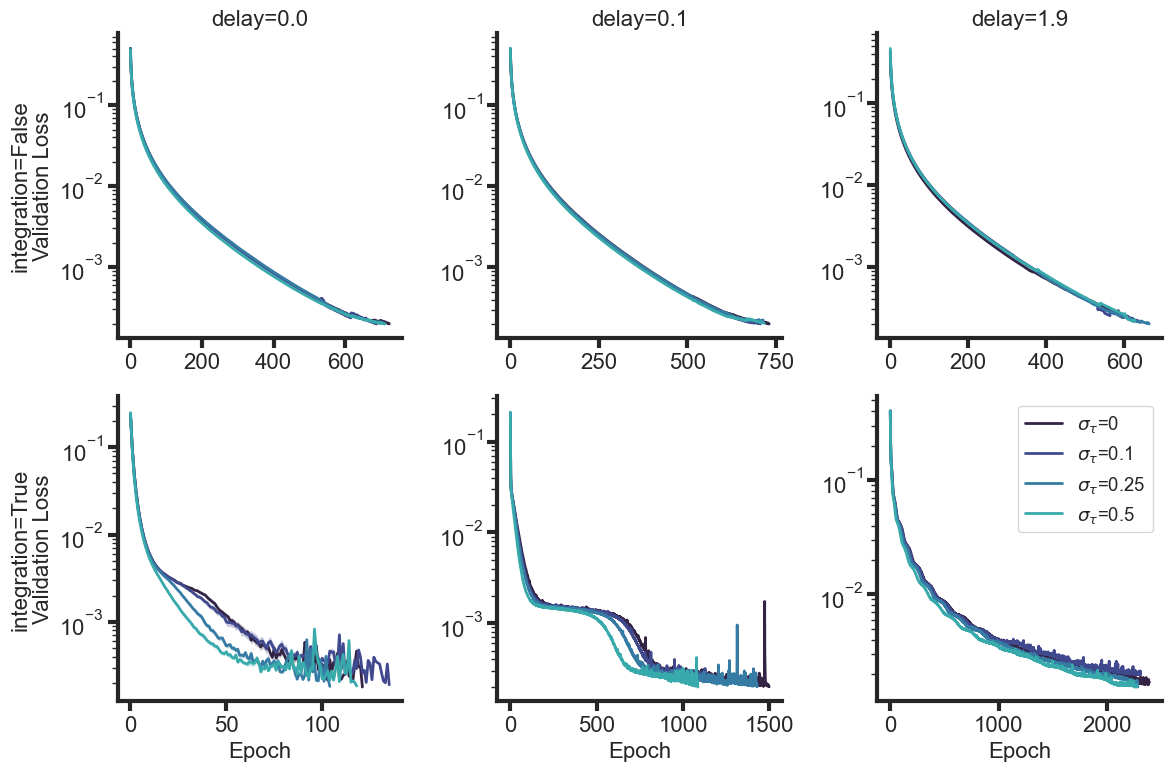

In [12]:
# 'Final' runs

def get_subdirs_final(dir, autocorr, zero_integration, kernel_tau, read_delay, dist_type, **kwargs):
    """Return glob-matched subdirs for a given distribution type."""
    if dist_type == 'normal':
        eta = kwargs['eta']
        pattern = f'{dir}/autocorr{autocorr}_ktau{kernel_tau}_zeroint{zero_integration}_delay{read_delay}_normal_eta{eta}*'
    elif dist_type == 'vanilla':
        tau = kwargs['tau']
        pattern = f'{dir}/autocorr{autocorr}_ktau{kernel_tau}_zeroint{zero_integration}_delay{read_delay}_vanilla{tau}*'
    elif dist_type == 'groups':
        tau_max = kwargs['tau'][1]
        prop = kwargs['prop']
        pattern = f'{dir}/autocorr{autocorr}_ktau{kernel_tau}_zeroint{zero_integration}_delay{read_delay}_groups{tau_max}_prop{prop}*'
    return glob.glob(pattern)

plot_configs = [
    # dict(dist_type='vanilla', tau=0.1, label='vanilla 0.1'),
    dict(dist_type='vanilla', tau=1.0, label=rf'$\sigma_\tau$=0'),
    # dict(dist_type='vanilla', tau=1.9, label='vanilla 1.9'),
    dict(dist_type='normal',  eta=0.1,  label=rf'$\sigma_\tau$=0.1'),
    dict(dist_type='normal',  eta=0.25, label=rf'$\sigma_\tau$=0.25'),
    dict(dist_type='normal',  eta=0.5,  label=rf'$\sigma_\tau$=0.5'),
    # dict(dist_type='groups',  tau=[0.1, 1.0],   prop=0.5, label='groups [0.1,1.0] p=0.5'),
    # dict(dist_type='groups',  tau=[0.1, 1.9], prop=0.2, label='groups [0.1,1.9] p=0.2'),
    # dict(dist_type='groups',  tau=[0.1, 1.9], prop=0.5, label='groups [0.1,1.9] p=0.5'),
    # dict(dist_type='groups',  tau=[0.1, 1.9], prop=0.8, label='groups [0.1,1.9] p=0.8'),
]

results_dir = '../rnn_results/final/'

kernel_taus = [1.9]
read_delays = [0.0, 0.1, 1.9]
autocorrs   = [0.9]
zero_integration_flags = [True, False]

cell_size = 4

for autocorr in autocorrs:
    row_configs = [(kt, zi) for kt in kernel_taus for zi in zero_integration_flags]
    n_rows, n_cols = len(row_configs), len(read_delays)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * cell_size, n_rows * cell_size))

    for i, (kernel_tau, zeroint) in enumerate(row_configs):
        for j, read_delay in enumerate(read_delays):
            ax = axes[i, j]

            for cfg in plot_configs:
                
                subdirs = get_subdirs_final(f'{results_dir}', autocorr, zeroint, kernel_tau, read_delay,
                                      cfg['dist_type'], **{k: v for k, v in cfg.items()
                                                           if k not in ('dist_type', 'label')})
                
                if (kernel_tau==1.9) & (zeroint==True) & ((read_delay==1.9)):
                    subdirs = get_subdirs_final('../rnn_results/final_missing/', autocorr, zeroint, kernel_tau, read_delay,
                                      cfg['dist_type'], **{k: v for k, v in cfg.items()
                                                           if k not in ('dist_type', 'label')})

                if not subdirs:
                    continue

                train_losses = [np.load(os.path.join(s, 'val_losses.npy')) for s in subdirs] # val_loss
                # train_losses = [np.load(os.path.join(s, 'weight_change_norm.npy')) for s in subdirs] # wcn

                max_len = max(len(x) for x in train_losses)
                padded = np.array([np.pad(x, (0, max_len - len(x)), mode='constant',constant_values=(np.nan,))
                                   for x in train_losses])

                mean, std = np.nanmean(padded, axis=0), np.nanstd(padded, axis=0)
                ax.plot(mean, label=cfg['label'])
                ax.fill_between(np.arange(max_len),
                                mean - std / np.sqrt(len(subdirs)),
                                mean + std / np.sqrt(len(subdirs)),
                                alpha=0.3)

            ax.set_yscale('log')

            if i == 0:
                ax.set_title(f'delay={read_delay}')
            if j == 0:
                ax.set_ylabel(f'integration={not zeroint}\nValidation Loss')
                # ax.set_ylabel(r"$\frac{\|W - W_0\|}{\|W_0\|}$",rotation=0)
            if i == n_rows - 1:
                ax.set_xlabel('Epoch')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    axes[-1, -1].legend(handles, labels, fontsize='small')
    # fig.suptitle(f'autocorr={autocorr}')
    plt.tight_layout()

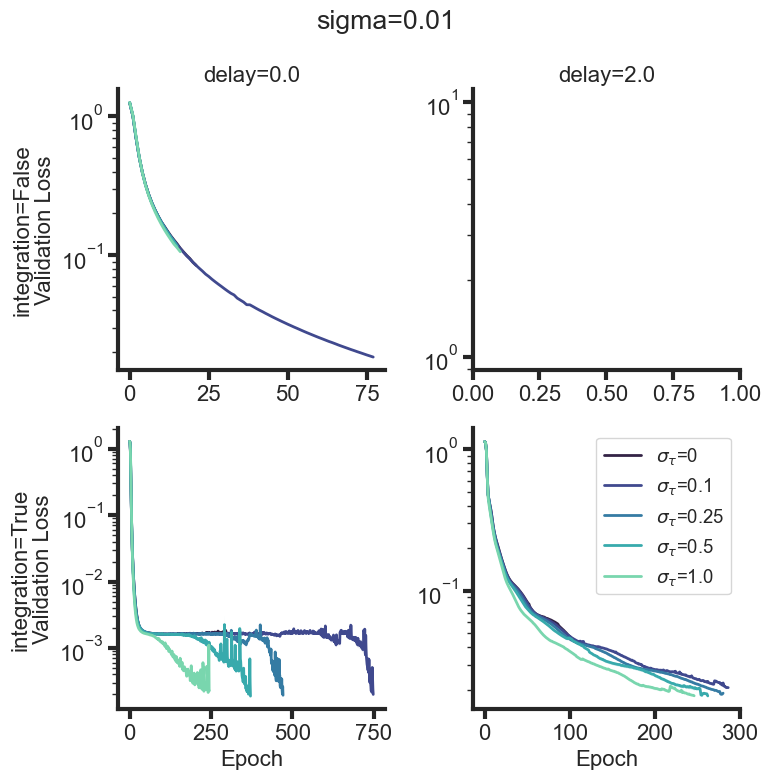

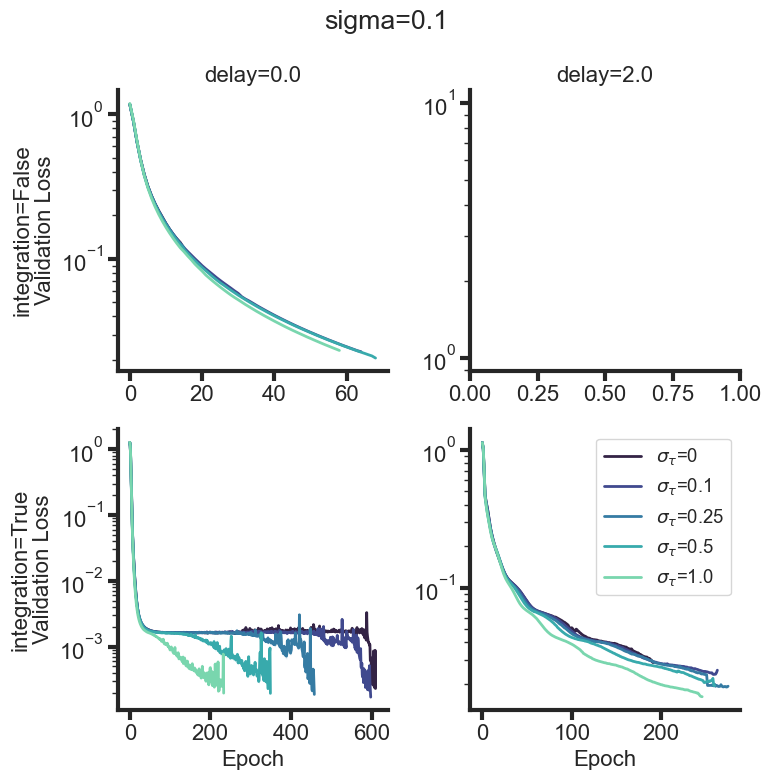

In [10]:
# I think this is working but im not sure (ai dan sigma)

def get_subdirs_final(dir, zero_integration, read_delay, dist_type, sigma, **kwargs):
    """Return glob-matched subdirs for a given distribution type."""
    if dist_type == 'normal':
        eta = kwargs['eta']
        pattern = f'{dir}/zeroint{zero_integration}_delay{read_delay}_normal_eta{eta}_sigma{sigma}*'
    elif dist_type == 'vanilla':
        tau = kwargs['tau']
        pattern = f'{dir}/zeroint{zero_integration}_delay{read_delay}_vanilla{tau}_sigma{sigma}*'
    elif dist_type == 'groups':
        tau_max = kwargs['tau'][1]
        prop = kwargs['prop']
        pattern = f'{dir}/zeroint{zero_integration}_delay{read_delay}_groups{tau_max}_sigma{sigma}*'
    return glob.glob(pattern)

plot_configs = [
    # dict(dist_type='vanilla', tau=0.1, label='vanilla 0.1'),
    dict(dist_type='vanilla', tau=1.0, label=rf'$\sigma_\tau$=0'),
    # dict(dist_type='vanilla', tau=2.0, label='vanilla 2.0'),
    dict(dist_type='normal',  eta=0.1,  label=rf'$\sigma_\tau$=0.1'),
    dict(dist_type='normal',  eta=0.25, label=rf'$\sigma_\tau$=0.25'),
    dict(dist_type='normal',  eta=0.5,  label=rf'$\sigma_\tau$=0.5'),
    dict(dist_type='normal',  eta=1.0,  label=rf'$\sigma_\tau$=1.0'),
    # dict(dist_type='groups',  tau=[0.1, 1.0], prop=0.5, label='groups [0.1,1.0] p=0.5'),
    # dict(dist_type='groups',  tau=[1.0, 2.0], prop=0.5, label='groups [1.0, 2.0] p=0.5'),
    # dict(dist_type='groups',  tau=[2.0, 0.1], prop=0.2, label='groups [0.1,2.0] p=0.2'),
    # dict(dist_type='groups',  tau=[2.0, 0.1], prop=0.5, label='groups [0.1,2.0] p=0.5'),
    # dict(dist_type='groups',  tau=[2.0, 0.1], prop=0.8, label='groups [0.1,2.0] p=0.8'),
]

results_dir = '../rnn_results/aidan_sigma/'

kernel_taus = [0.9]
sigmas = [0.01, 0.1]
read_delays = [0.0, 2.0]
zero_integration_flags = [True, False]

cell_size = 4

for sigma in sigmas:
    row_configs = [(kt, zi) for kt in kernel_taus for zi in zero_integration_flags]
    n_rows, n_cols = len(row_configs), len(read_delays)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * cell_size, n_rows * cell_size))

    for i, (kernel_tau, zeroint) in enumerate(row_configs):
        for j, read_delay in enumerate(read_delays):
            ax = axes[i, j]

            for cfg in plot_configs:
                
                subdirs = get_subdirs_final(f'{results_dir}', zeroint, read_delay, cfg['dist_type'], sigma, 
                **{k: v for k, v in cfg.items() if k not in ('dist_type', 'label')})

                if not subdirs:
                    continue

                train_losses = [np.load(os.path.join(s, 'val_losses.npy')) for s in subdirs] # val_loss
                # train_losses = [np.load(os.path.join(s, 'weight_change_norm.npy')) for s in subdirs] # wcn

                max_len = max(len(x) for x in train_losses)
                padded = np.array([np.pad(x, (0, max_len - len(x)), mode='constant',constant_values=(np.nan,))
                                   for x in train_losses])

                mean, std = np.nanmean(padded, axis=0), np.nanstd(padded, axis=0)
                ax.plot(mean, label=cfg['label'])
                ax.fill_between(np.arange(max_len),
                                mean - std / np.sqrt(len(subdirs)),
                                mean + std / np.sqrt(len(subdirs)),
                                alpha=0.3)

            ax.set_yscale('log')

            if i == 0:
                ax.set_title(f'delay={read_delay}')
            if j == 0:
                ax.set_ylabel(f'integration={not zeroint}\nValidation Loss')
                # ax.set_ylabel(r"$\frac{\|W - W_0\|}{\|W_0\|}$",rotation=0)
            if i == n_rows - 1:
                ax.set_xlabel('Epoch')

    handles, labels = axes[-1, -1].get_legend_handles_labels()
    axes[-1, -1].legend(handles, labels, fontsize='small')
    fig.suptitle(f'sigma={sigma}')
    plt.tight_layout()